#***GoogleNet (Inception) Pretrained Pytorch Implementation***

***1.Imports***

***PIL stands for Python Imaging Library. It is a Python library used to open, manipulate, process, and save images.***

***Today, the original PIL is no longer maintained. We generally use Pillow, which is its modern replacement.***

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
import json

***2.Load Pretrained Inception v3 Model***

In [2]:
# Load Pretrained Inception v3 Model
model=models.inception_v3(pretrained=True)
#set to evaluation
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 156MB/s] 


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

***3. Image Transformations***

In [3]:
#Image Transformations
def tranform_image(img_path):
  transform=transforms.Compose([
      transforms.Resize((299,299)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485,0.456,0.406],
                           std=[0.229,0.224,0.225])
  ])
  img = Image.open(img_path).convert("RGB")
  return transform(img).unsqueeze(0) # Add batch dimension

***4. Model Inferencing & Loading Class Labels***

In [4]:
!wget https://raw.githubusercontent.com/pytorch/hub/refs/heads/master/imagenet_classes.txt

--2026-08-19 18:48:32--  https://raw.githubusercontent.com/pytorch/hub/refs/heads/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0s      

2026-08-19 18:48:33 (70.9 MB/s) - ‘imagenet_classes.txt’ saved [10472/10472]



In [5]:
# Inference
def predict(img_tensor,model):
  with torch.no_grad():
    outputs = model(img_tensor)
  return outputs,torch.nn.functional.softmax(outputs,dim=1)[0]

In [6]:
# load class label
with open('/content/imagenet_classes.txt') as f:
  lbl = [line.strip() for line in f.readlines()]

***6. Inferencing & Visualizing Results***

In [7]:
#image downloader function
import requests

def download_image(url,filename):
  try:
    response = requests.get(url,stream=True)
    response.raise_for_status()
    with open(filename,'wb') as f:
      for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
    print(f"Image Download successfully at {filename}")
  except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")


# example usage
url = "https://cdn.britannica.com/33/238533-050-2E2D04F4/Indian-cobra-naja-naja-venonmous-snake-reptile-hood.jpg"
filename = "peacock.jpg"

download_image(url,filename)

Image Download successfully at peacock.jpg


***7. Visualize Image and Prediction***

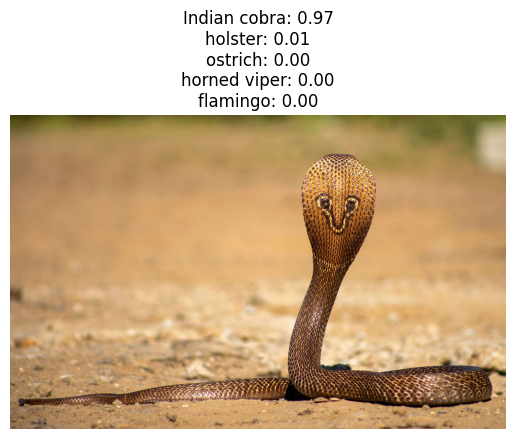

In [13]:
# Visualize Image and Prediction
def visualize_img(img_path,prediction,labels):
  image = Image.open(img_path)
  plt.imshow(image)
  plt.axis('off')

  #get 5 top predictions
  top5_prob,top5_catid = torch.topk(prediction,5)
  top5_lbls = [labels[i] for i in top5_catid]

  # show predictions
  plt.title("\n".join([f"{label}: {prob:.2f}" for label,prob in zip(top5_lbls,top5_prob)]))
  plt.show()


#example usage
img_pth = '/content/peacock.jpg'
img_tensor = tranform_image(img_pth)
outputs,prediction = predict(img_tensor,model)
visualize_img(img_pth,prediction,lbl)